In [8]:
import pandas as pd

df = pd.read_csv('ecommerce_dataset_updated (1).csv')
print("=" * 60)
print("E-COMMERCE DATASET EXPLORATION")
print("=" * 60)

print("\n1. DATASET SHAPE")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\n2. COLUMN NAMES")
print(df.columns.tolist())

print("\n3. FIRST 5 ROWS")
print(df.head())

print("\n4. DATA TYPES")
print(df.dtypes)

print("\n5. MISSING VALUES")
print(df.isnull().sum())

print("\n6. BASIC STATS")
print(df.describe())

E-COMMERCE DATASET EXPLORATION

1. DATASET SHAPE
Rows: 3660
Columns: 8

2. COLUMN NAMES
['User_ID', 'Product_ID', 'Category', 'Price (Rs.)', 'Discount (%)', 'Final_Price(Rs.)', 'Payment_Method', 'Purchase_Date']

3. FIRST 5 ROWS
    User_ID  Product_ID  Category  Price (Rs.)  Discount (%)  \
0  337c166f  f414122f-e    Sports        36.53            15   
1  d38a19bf  fde50f9c-5  Clothing       232.79            20   
2  d7f5f0b0  0d96fc90-3    Sports       317.02            25   
3  395d4994  964fc44b-d      Toys       173.19            25   
4  a83c145c  d70e2fc6-e    Beauty       244.80            20   

   Final_Price(Rs.) Payment_Method Purchase_Date  
0             31.05    Net Banking    12-11-2024  
1            186.23    Net Banking    09-02-2024  
2            237.76    Credit Card    01-09-2024  
3            129.89            UPI    01-04-2024  
4            195.84    Net Banking    27-09-2024  

4. DATA TYPES
User_ID              object
Product_ID           object
Category 

In [9]:

print("BEFORE CLEANING:")
print(f"Total rows: {len(df)}")
print(f"Missing values:\n{df.isnull().sum()}\n")
df = df.drop_duplicates()
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'], format='%d-%m-%Y')
df['Purchase_Year'] = df['Purchase_Date'].dt.year
df['Purchase_Month'] = df['Purchase_Date'].dt.month
df['Purchase_Day'] = df['Purchase_Date'].dt.day
print("AFTER CLEANING:")
print(f"Total rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\n✓ Data cleaned successfully!")

BEFORE CLEANING:
Total rows: 3660
Missing values:
User_ID             0
Product_ID          0
Category            0
Price (Rs.)         0
Discount (%)        0
Final_Price(Rs.)    0
Payment_Method      0
Purchase_Date       0
dtype: int64

AFTER CLEANING:
Total rows: 3660
Columns: ['User_ID', 'Product_ID', 'Category', 'Price (Rs.)', 'Discount (%)', 'Final_Price(Rs.)', 'Payment_Method', 'Purchase_Date', 'Purchase_Year', 'Purchase_Month', 'Purchase_Day']

✓ Data cleaned successfully!


In [10]:
print("=" * 70)
print("E-COMMERCE SALES ANALYSIS")
print("=" * 70)
print("\n1. BUSINESS METRICS")
print("-" * 70)
total_revenue = df['Final_Price(Rs.)'].sum()
total_purchases = len(df)
total_customers = df['User_ID'].nunique()
avg_purchase_value = total_revenue / total_purchases

print(f"Total Revenue: Rs. {total_revenue:,.2f}")
print(f"Total Individual Purchases: {total_purchases:,}")
print(f"Total Unique Customers: {total_customers:,}")
print(f"Average Purchase Value: Rs. {avg_purchase_value:,.2f}")
print("\n2. TOP 10 PRODUCTS BY REVENUE")
print("-" * 70)
top_products_by_revenue = df.groupby('Product_ID')['Final_Price(Rs.)'].sum().sort_values(ascending=False).head(10)
print(top_products_by_revenue)
print("\n3. TOP 10 CUSTOMERS BY SPENDING")
print("-" * 70)
top_customers_by_spending = df.groupby('User_ID')['Final_Price(Rs.)'].sum().sort_values(ascending=False).head(10)
print(top_customers_by_spending)
print("\n4. REVENUE BY MONTH")
print("-" * 70)
monthly_revenue = df.groupby('Purchase_Month')['Final_Price(Rs.)'].sum().sort_index()
print(monthly_revenue)
print("\n5. TOP 10 PRODUCTS BY COUNT OF PURCHASES")
print("-" * 70)
top_products_by_count = df['Product_ID'].value_counts().head(10)
print(top_products_by_count)
print("\n6. CUSTOMER SPENDING STATISTICS")
print("-" * 70)
customer_spending = df.groupby('User_ID')['Final_Price(Rs.)'].sum()
print(f"Average customer spending: Rs. {customer_spending.mean():,.2f}")
print(f"Max customer spending: Rs. {customer_spending.max():,.2f}")
print(f"Min customer spending: Rs. {customer_spending.min():,.2f}")

E-COMMERCE SALES ANALYSIS

1. BUSINESS METRICS
----------------------------------------------------------------------
Total Revenue: Rs. 757,278.08
Total Individual Purchases: 3,660
Total Unique Customers: 3,660
Average Purchase Value: Rs. 206.91

2. TOP 10 PRODUCTS BY REVENUE
----------------------------------------------------------------------
Product_ID
5a4c2797-7    496.82
2a8fff8b-4    495.02
475d4cf1-c    493.04
e88dc97f-5    492.41
67d7c91c-b    491.70
128bb94a-4    487.06
28714133-6    486.79
585b0773-2    484.56
3be497cb-0    480.49
6390f2ea-8    479.63
Name: Final_Price(Rs.), dtype: float64

3. TOP 10 CUSTOMERS BY SPENDING
----------------------------------------------------------------------
User_ID
8b885340    496.82
20797b76    495.02
d8970dd2    493.04
da7bc76a    492.41
68722b9b    491.70
05e6557c    487.06
67abda0a    486.79
d646700c    484.56
edb89577    480.49
f9e89622    479.63
Name: Final_Price(Rs.), dtype: float64

4. REVENUE BY MONTH
-----------------------------

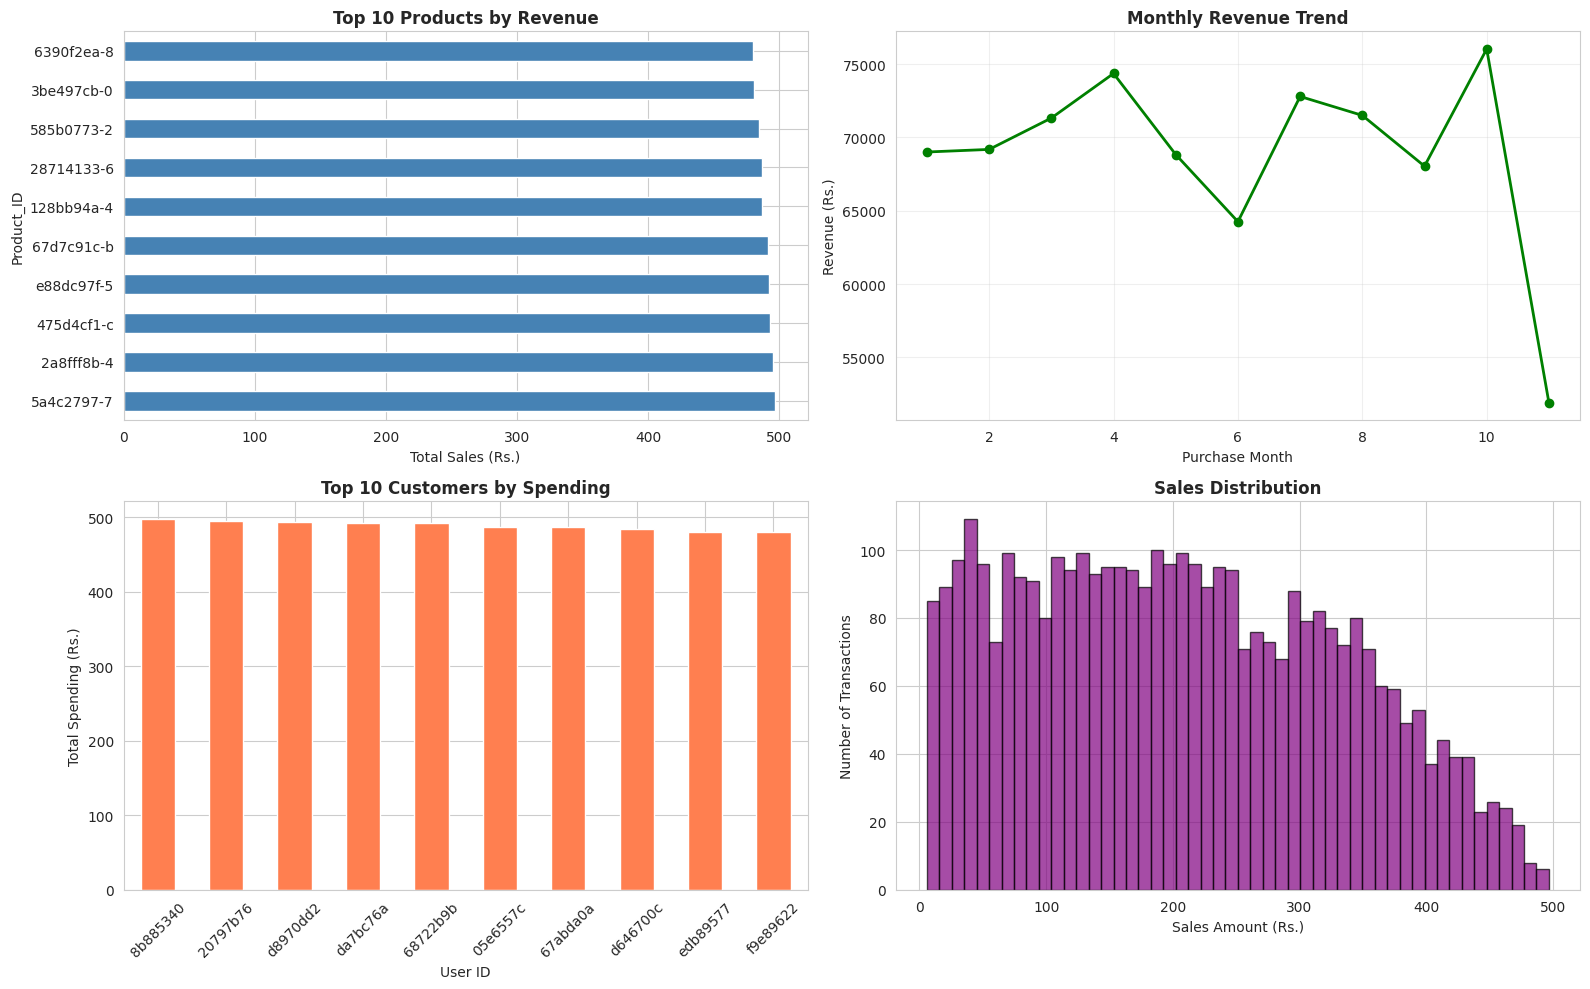

✓ Dashboard created!


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Create dashboard with 4 charts
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# CHART 1: Top 10 Products by Revenue
ax1 = axes[0, 0]
top_products = df.groupby('Product_ID')['Final_Price(Rs.)'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Top 10 Products by Revenue', fontsize=12, fontweight='bold')
ax1.set_xlabel('Total Sales (Rs.)')

# CHART 2: Monthly Revenue Trend
ax2 = axes[0, 1]
monthly = df.groupby('Purchase_Month')['Final_Price(Rs.)'].sum().sort_index()
monthly.plot(kind='line', ax=ax2, color='green', marker='o', linewidth=2)
ax2.set_title('Monthly Revenue Trend', fontsize=12, fontweight='bold')
ax2.set_xlabel('Purchase Month')
ax2.set_ylabel('Revenue (Rs.)')
ax2.grid(True, alpha=0.3)

# CHART 3: Top 10 Customers
ax3 = axes[1, 0]
top_customers = df.groupby('User_ID')['Final_Price(Rs.)'].sum().sort_values(ascending=False).head(10)
top_customers.plot(kind='bar', ax=ax3, color='coral')
ax3.set_title('Top 10 Customers by Spending', fontsize=12, fontweight='bold')
ax3.set_xlabel('User ID')
ax3.set_ylabel('Total Spending (Rs.)')
ax3.tick_params(axis='x', rotation=45)

# CHART 4: Sales Distribution
ax4 = axes[1, 1]
ax4.hist(df['Final_Price(Rs.)'], bins=50, color='purple', edgecolor='black', alpha=0.7)
ax4.set_title('Sales Distribution', fontsize=12, fontweight='bold')
ax4.set_xlabel('Sales Amount (Rs.)')
ax4.set_ylabel('Number of Transactions')

plt.tight_layout()
plt.savefig('ecommerce_dashboard.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Dashboard created!")

In [12]:
df.to_csv('cleaned_ecommerce_data.csv', index=False)
insights = f"""
E-COMMERCE SALES ANALYSIS REPORT
=====================================

BUSINESS METRICS:
- Total Revenue: Rs. {df['Final_Price(Rs.)'].sum():,.2f}
- Total Individual Purchases: {len(df):,}
- Total Unique Customers: {df['User_ID'].nunique():,}
- Avg Purchase Value: Rs. {df['Final_Price(Rs.)'].sum() / len(df):,.2f}

TOP PRODUCT: {df.groupby('Product_ID')['Final_Price(Rs.)'].sum().sort_values(ascending=False).index[0]}

TOP CUSTOMER: User ID {df.groupby('User_ID')['Final_Price(Rs.)'].sum().sort_values(ascending=False).index[0]}

Monthly Revenue Trend:
{df.groupby('Purchase_Month')['Final_Price(Rs.)'].sum().to_string()}
"""

with open('sales_insights.txt', 'w') as f:
    f.write(insights)

print("✓ Files saved!")

✓ Files saved!
